<a href="https://colab.research.google.com/github/oguzcosskun/explainable-credit-nn/blob/main/FNN_Model_w_Methods_Metrics_Implemented.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CAPSTONE — Explainable Neural Networks in Credit Decisions
# Stage 1 : Data Pipeline + FNN Training (German Credit)
# CNN removed; SHAP / IG / DiCE will be added in next stage
# ============================================================

import os, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (roc_auc_score, recall_score,
                             precision_score, f1_score,
                             confusion_matrix, classification_report)
from google.colab import drive

# ── 0. REPRODUCIBILITY ────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── 1. DRIVE SETUP ────────────────────────────────────────────
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/capstone'
for folder in ['data', 'models', 'outputs']:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)
    print(f"Ready: {os.path.join(base_path, folder)}")

# ============================================================
# 2. UNIFIED PREPROCESSING WRAPPER
#    Supports: German Credit, HELOC, Adult Income,
#              Give Me Some Credit
#    Returns  : X_fnn (one-hot + scaled)
#               X_tabnet (label-enc + scaled)
#               y (binary Series, 1 = default/positive class)
# ============================================================

def load_and_preprocess(dataset_name: str):
    """
    Unified entry point for all four benchmark datasets.
    Each sub-loader normalises the target to:
        1 = high-risk / default / positive class
        0 = low-risk  / non-default

    Returns
    -------
    X_fnn_scaled    : pd.DataFrame  (one-hot encoded + MinMax scaled)
    X_tabnet_scaled : pd.DataFrame  (label encoded   + MinMax scaled)
    y               : pd.Series     (binary int)
    cat_cols        : list[str]
    num_cols        : list[str]
    """
    loaders = {
        "german":  _load_german,
        "heloc":   _load_heloc,
        "adult":   _load_adult,
        "gmsc":    _load_gmsc,
    }
    key = dataset_name.lower().strip()
    if key not in loaders:
        raise ValueError(f"Unknown dataset '{dataset_name}'. "
                         f"Choose from: {list(loaders.keys())}")

    X, y = loaders[key]()
    return _preprocess(X, y)


# ── Individual loaders ────────────────────────────────────────

def _load_german():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/statlog/german/german.data")
    col_names = [
        "checking_account", "duration", "credit_history", "purpose",
        "credit_amount", "savings_account", "employment",
        "installment_rate", "personal_status", "other_debtors",
        "residence_since", "property", "age", "other_installments",
        "housing", "existing_credits", "job", "dependents",
        "telephone", "foreign_worker", "target"
    ]
    df = pd.read_csv(url, sep=" ", header=None, names=col_names)
    df["target"] = df["target"].map({1: 0, 2: 1})   # 1=bad=default
    X = df.drop(columns=["target"])
    y = df["target"]
    print(f"[German Credit] shape={df.shape}, "
          f"default_rate={y.mean():.2%}")
    return X, y


import os
import pandas as pd
import numpy as np

# ── 1. HELOC Loader ──────────────────────────────────────────
def _load_heloc():
    """
    HELOC Loader: Drive -> Local -> Mirror Fallback
    Target: 1 = Bad (Default), 0 = Good
    """
    drive_path = os.path.join(base_path, "data", "heloc_dataset_v1 (1).csv")
    local_path = "/content/drive/MyDrive/capstone/data/heloc_dataset_v1 (1).csv" # Senin yüklediğin geçici dosya
    mirror_url = "https://raw.githubusercontent.com/vcerqueira/heloc/main/heloc_dataset_v1.csv"

    if os.path.exists(drive_path):
        df = pd.read_csv(drive_path)
    elif os.path.exists(local_path):
        print(f"  [HELOC] Yerel dosya bulundu: {local_path}")
        df = pd.read_csv(local_path)
    else:
        print("  [HELOC] Drive'da bulunamadı, mirror üzerinden indiriliyor...")
        df = pd.read_csv(mirror_url)

    df.columns = [c.strip() for c in df.columns]
    df["target"] = (df["RiskPerformance"].str.strip() == "Bad").astype(int)
    X = df.drop(columns=["RiskPerformance", "target"])
    X = X.replace([-7, -8, -9], np.nan) # Sentinel values handling [cite: 247]
    return X, df["target"]

# ── 2. Adult Income Loader ───────────────────────────────────
def _load_adult():
    """
    UCI Adult Income Loader.
    Target: 1 = >50K (Positive), 0 = <=50K
    """
    drive_path = os.path.join(base_path, "data", "adult.data")
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
    col_names = [
        "age", "workclass", "fnlwgt", "education", "education_num",
        "marital_status", "occupation", "relationship", "race", "sex",
        "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
    ]

    if os.path.exists(drive_path):
        df = pd.read_csv(drive_path, header=None, names=col_names, na_values=" ?", skipinitialspace=True)
    else:
        print("  [Adult] Drive'da bulunamadı, UCI üzerinden indiriliyor...")
        df = pd.read_csv(url, header=None, names=col_names, na_values=" ?", skipinitialspace=True)

    df["target"] = (df["income"].str.strip().str.startswith(">50K")).astype(int)
    X = df.drop(columns=["income", "target"])
    return X, df["target"]

# ── 3. Give Me Some Credit (GMSC) Loader ──────────────────────
def _load_gmsc():
    """
    GMSC Loader.
    Target: 1 = Default (SeriousDlqin2yrs)
    """
    drive_path = os.path.join(base_path, "data", "cs-training.csv")
    mirror_url = "https://raw.githubusercontent.com/tomasen/GiveMeSomeCredit/master/cs-training.csv"

    if os.path.exists(drive_path):
        df = pd.read_csv(drive_path, index_col=0)
    else:
        print("  [GMSC] Drive'da bulunamadı, mirror üzerinden indiriliyor...")
        df = pd.read_csv(mirror_url, index_col=0)

    df.columns = [c.strip() for c in df.columns]
    y = df["SeriousDlqin2yrs"].astype(int)
    X = df.drop(columns=["SeriousDlqin2yrs"])

    # 96/98 sentinel cleaning [cite: 247]
    for col in [c for c in X.columns if "NumberOfTime" in c]:
        X[col] = X[col].replace([96, 98], np.nan)

    return X, y

# ── Shared preprocessing logic ────────────────────────────────

def _preprocess(X: pd.DataFrame, y: pd.Series):
    """
    1. Missing values  : median for numeric, mode for categorical
    2. Encoding        : One-Hot (FNN) vs Label (TabNet)
    3. Scaling         : MinMax on both versions
    """
    cat_cols = X.select_dtypes(include="object").columns.tolist()
    num_cols = X.select_dtypes(include="number").columns.tolist()
    print(f"  Categorical cols ({len(cat_cols)}): {cat_cols}")
    print(f"  Numerical   cols ({len(num_cols)}): {num_cols}")

    # ── Missing value imputation ──────────────────────────────
    for col in num_cols:
        if X[col].isnull().any():
            X[col].fillna(X[col].median(), inplace=True)
    for col in cat_cols:
        if X[col].isnull().any():
            X[col].fillna(X[col].mode()[0], inplace=True)

    # ── VERSION 1: FNN — One-Hot Encoding ────────────────────
    X_fnn = pd.get_dummies(X, columns=cat_cols)
    scaler_fnn = MinMaxScaler()
    X_fnn_scaled = pd.DataFrame(
        scaler_fnn.fit_transform(X_fnn),
        columns=X_fnn.columns
    )

    # ── VERSION 2: TabNet — Label Encoding ───────────────────
    X_tabnet = X.copy()
    le = LabelEncoder()
    for col in cat_cols:
        X_tabnet[col] = le.fit_transform(X_tabnet[col].astype(str))
    scaler_tabnet = MinMaxScaler()
    X_tabnet_scaled = pd.DataFrame(
        scaler_tabnet.fit_transform(X_tabnet),
        columns=X_tabnet.columns
    )

    print(f"  FNN input dim    : {X_fnn_scaled.shape[1]}")
    print(f"  TabNet input dim : {X_tabnet_scaled.shape[1]}")
    return X_fnn_scaled, X_tabnet_scaled, y.reset_index(drop=True), \
           cat_cols, num_cols


# ============================================================
# 3. TRAIN / VAL / TEST SPLIT  (stratified)
# ============================================================

def make_splits(X_fnn, X_tabnet, y,
                test_size=0.20, val_size=0.15, seed=SEED):
    """
    First carve out test set, then split remaining into train/val.
    Same random state ensures FNN and TabNet share identical indices.
    """
    # Step 1: train+val vs test
    X_fnn_tv, X_fnn_test, \
    X_tab_tv, X_tab_test, \
    y_tv, y_test = train_test_split(
        X_fnn, X_tabnet, y,
        test_size=test_size, random_state=seed, stratify=y
    )
    # Step 2: train vs val
    X_fnn_train, X_fnn_val, \
    X_tab_train, X_tab_val, \
    y_train, y_val = train_test_split(
        X_fnn_tv, X_tab_tv, y_tv,
        test_size=val_size, random_state=seed, stratify=y_tv
    )

    print(f"\nSplit sizes → train: {len(y_train)}, "
          f"val: {len(y_val)}, test: {len(y_test)}")
    for split_name, yy in [("train", y_train),
                            ("val",   y_val),
                            ("test",  y_test)]:
        print(f"  Default rate [{split_name}]: {yy.mean():.2%}")

    return (X_fnn_train, X_fnn_val, X_fnn_test,
            X_tab_train, X_tab_val, X_tab_test,
            y_train, y_val, y_test)


# ============================================================
# 4. FNN ARCHITECTURE
# ============================================================

class CreditFNN(nn.Module):
    """
    3-layer Feedforward Network for binary credit classification.
    Uses BCEWithLogitsLoss → output layer returns raw logit (no sigmoid).
    """
    def __init__(self, input_dim: int, hidden1=64, hidden2=32,
                 dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),          # stabilises training
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1)             # raw logit — no sigmoid
        )

    def forward(self, x):
        return self.net(x)                    # shape: (batch, 1)


# ============================================================
# 5. TRAINING LOOP
# ============================================================

def train_fnn(X_train, X_val, y_train, y_val,
              dataset_name="german",
              hidden1=64, hidden2=32, dropout=0.4,
              lr=1e-3, weight_decay=1e-4,
              batch_size=32, max_epochs=100, patience=10):
    """
    Trains CreditFNN with:
    - Weighted BCE loss (handles class imbalance dynamically)
    - Adam + L2 regularisation (weight_decay)
    - Early stopping on validation loss
    - Best model checkpoint saved to Drive
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nTraining on: {device}")

    # ── Tensors ──────────────────────────────────────────────
    Xtr = torch.tensor(X_train.values, dtype=torch.float32).to(device)
    ytr = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1).to(device)
    Xvl = torch.tensor(X_val.values,   dtype=torch.float32).to(device)
    yvl = torch.tensor(y_val.values,   dtype=torch.float32).view(-1,1).to(device)

    loader = DataLoader(TensorDataset(Xtr, ytr),
                        batch_size=batch_size, shuffle=True)

    # ── Dynamic pos_weight ───────────────────────────────────
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    pos_w = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
    print(f"  pos_weight = {pos_w.item():.3f}  "
          f"(neg={n_neg}, pos={n_pos})")

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)

    input_dim = X_train.shape[1]
    model = CreditFNN(input_dim, hidden1, hidden2, dropout).to(device)
    optimizer = optim.Adam(model.parameters(),
                           lr=lr, weight_decay=weight_decay)

    # ── Early stopping ───────────────────────────────────────
    best_val_loss = float('inf')
    best_epoch    = 0
    counter       = 0
    ckpt_path     = os.path.join(base_path, 'models',
                                 f'fnn_best_{dataset_name}.pt')

    for epoch in range(1, max_epochs + 1):
        # Train
        model.train()
        for Xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()

        # Validate
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(Xvl), yvl).item()

        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d} | val_loss: {val_loss:.4f} "
                  f"| best: {best_val_loss:.4f} (ep {best_epoch})")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch    = epoch
            counter       = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            counter += 1
            if counter >= patience:
                print(f"\n  Early stopping at epoch {epoch}. "
                      f"Best epoch: {best_epoch}")
                break

    print(f"  Best val_loss: {best_val_loss:.4f} at epoch {best_epoch}")
    # Reload best weights
    model.load_state_dict(torch.load(ckpt_path,
                                     map_location=device))
    return model, device


# ============================================================
# 6. EVALUATION
# ============================================================

def evaluate_fnn(model, device, X_test, y_test,
                 dataset_name="german",
                 threshold=0.5):
    """
    Evaluates the trained FNN on the test set.
    Metrics: AUC-ROC, Recall, Precision, F1, Confusion Matrix.
    Also tries threshold = 0.4 for higher recall on minority class
    (important: missing a defaulter costs more than false rejection).
    Saves results to Drive.
    """
    model.eval()
    Xte = torch.tensor(X_test.values, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(Xte).cpu().numpy().flatten()

    probs = 1 / (1 + np.exp(-logits))   # sigmoid manually applied

    auc = roc_auc_score(y_test, probs)
    print(f"\n{'='*50}")
    print(f"  Dataset : {dataset_name.upper()}")
    print(f"  AUC-ROC : {auc:.4f}")
    print(f"{'='*50}")

    results = {}
    for thr in [threshold, 0.4, 0.45]:
        preds = (probs >= thr).astype(int)
        rec  = recall_score(y_test, preds, zero_division=0)
        prec = precision_score(y_test, preds, zero_division=0)
        f1   = f1_score(y_test, preds, zero_division=0)
        cm   = confusion_matrix(y_test, preds)
        print(f"\n  Threshold = {thr}")
        print(f"  Recall    = {rec:.4f}  (key metric)")
        print(f"  Precision = {prec:.4f}")
        print(f"  F1        = {f1:.4f}")
        print(f"  Confusion Matrix:\n{cm}")
        results[thr] = {"auc": auc, "recall": rec,
                        "precision": prec, "f1": f1}

    print(f"\n  Full report (threshold={threshold}):")
    preds_main = (probs >= threshold).astype(int)
    print(classification_report(y_test, preds_main,
                                 target_names=["Good", "Default"]))

    # Save probabilities for SHAP / DiCE stage
    out_path = os.path.join(base_path, 'outputs',
                             f'fnn_probs_{dataset_name}.npy')
    np.save(out_path, probs)
    print(f"  Probabilities saved → {out_path}")

    return probs, results


# ============================================================
# 7. SAVE SPLITS TO DRIVE  (for reproducibility + XAI stage)
# ============================================================

def save_splits(dataset_name,
                X_fnn_train, X_fnn_val, X_fnn_test,
                X_tab_train, X_tab_val, X_tab_test,
                y_train, y_val, y_test):
    d = os.path.join(base_path, 'data', dataset_name)
    os.makedirs(d, exist_ok=True)
    splits = {
        'X_train_fnn': X_fnn_train, 'X_val_fnn':  X_fnn_val,
        'X_test_fnn':  X_fnn_test,
        'X_train_tab': X_tab_train, 'X_val_tab':  X_tab_val,
        'X_test_tab':  X_tab_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
    }
    for name, df in splits.items():
        p = os.path.join(d, f'{name}.csv')
        (df if isinstance(df, pd.DataFrame)
           else df.to_frame()).to_csv(p, index=False)
    print(f"All splits saved to {d}")


# ============================================================
# 8. MAIN  — run everything for German Credit
#    (change dataset_name to run on others once files are in Drive)
# ============================================================

if __name__ == "__main__":

    DATASET = "german"   # change to "heloc", "adult", "gmsc"

    # ── Step 1: Load & preprocess ────────────────────────────
    print(f"\n{'='*50}")
    print(f" Loading dataset: {DATASET.upper()}")
    print(f"{'='*50}")
    X_fnn, X_tab, y, cat_cols, num_cols = load_and_preprocess(DATASET)

    # ── Step 2: Train / Val / Test split ─────────────────────
    (X_fnn_train, X_fnn_val, X_fnn_test,
     X_tab_train, X_tab_val, X_tab_test,
     y_train, y_val, y_test) = make_splits(X_fnn, X_tab, y)

    # ── Step 3: Save splits ──────────────────────────────────
    save_splits(DATASET,
                X_fnn_train, X_fnn_val, X_fnn_test,
                X_tab_train, X_tab_val, X_tab_test,
                y_train, y_val, y_test)

    # ── Step 4: Train FNN ────────────────────────────────────
    model, device = train_fnn(
        X_fnn_train, X_fnn_val, y_train, y_val,
        dataset_name=DATASET,
        hidden1=64, hidden2=32, dropout=0.4,
        lr=1e-3, weight_decay=1e-4,
        batch_size=32, max_epochs=100, patience=10
    )

    # ── Step 5: Evaluate ─────────────────────────────────────
    probs, results = evaluate_fnn(
        model, device, X_fnn_test, y_test,
        dataset_name=DATASET,
        threshold=0.5
    )

    print("\nDone. Next step: SHAP / IG / DiCE integration.")


Mounted at /content/drive
Ready: /content/drive/MyDrive/capstone/data
Ready: /content/drive/MyDrive/capstone/models
Ready: /content/drive/MyDrive/capstone/outputs

 Loading dataset: GERMAN
[German Credit] shape=(1000, 21), default_rate=30.00%
  Categorical cols (13): ['checking_account', 'credit_history', 'purpose', 'savings_account', 'employment', 'personal_status', 'other_debtors', 'property', 'other_installments', 'housing', 'job', 'telephone', 'foreign_worker']
  Numerical   cols (7): ['duration', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'dependents']
  FNN input dim    : 61
  TabNet input dim : 20

Split sizes → train: 680, val: 120, test: 200
  Default rate [train]: 30.00%
  Default rate [val]: 30.00%
  Default rate [test]: 30.00%
All splits saved to /content/drive/MyDrive/capstone/data/german

Training on: cpu
  pos_weight = 2.333  (neg=476, pos=204)
  Epoch  10 | val_loss: 0.8386 | best: 0.8325 (ep 8)

  Early stopping at epoch 18. Best

In [ ]:
!pip install shap captum dice-ml --quiet
!pip install git+https://github.com/AI4LIFE-GROUP/OpenXAI.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.2 MB/s eta 0:00:00
  Cloning https://github.com/AI4LIFE-GROUP/OpenXAI.git to /tmp/pip-req-build-4s3a5b8p
  Running command git clone --filter=blob:none --quiet https://github.com/AI4LIFE-GROUP/OpenXAI.git /tmp/pip-req-build-4s3a5b8p
  Resolved https://github.com/AI4LIFE-GROUP/OpenXAI.git to commit a18288620464250856b55234266a6d1dabb64656
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.2/376.2 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 15.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.7 MB/s eta 0:00:00
  

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import shap
from captum.attr import IntegratedGradients
import dice_ml
warnings.filterwarnings("ignore")

# Stage 1'deki sabitler (aynı notebook'taysa zaten tanımlı,
# farklı session'daysa tekrar tanımla)
SEED      = 42
base_path = '/content/drive/MyDrive/capstone'
DATASET   = "german"   # çalıştırmak istediğin dataset

# ── CreditFNN tanımı (Stage 1'den kopyala ya da import et) ──
class CreditFNN(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1)
        )
    def forward(self, x):
        return self.net(x)

# ── Kaydedilmiş split'leri yükle ────────────────────────────
d = os.path.join(base_path, 'data', DATASET)

X_train = pd.read_csv(os.path.join(d, 'X_train_fnn.csv'))
X_val   = pd.read_csv(os.path.join(d, 'X_val_fnn.csv'))
X_test  = pd.read_csv(os.path.join(d, 'X_test_fnn.csv'))
y_train = pd.read_csv(os.path.join(d, 'y_train.csv')).squeeze()
y_val   = pd.read_csv(os.path.join(d, 'y_val.csv')).squeeze()
y_test  = pd.read_csv(os.path.join(d, 'y_test.csv')).squeeze()

feature_names = X_train.columns.tolist()
input_dim     = len(feature_names)

# ── Modeli yükle ─────────────────────────────────────────────
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = CreditFNN(input_dim).to(device)
ckpt_path = os.path.join(base_path, 'models', f'fnn_best_{DATASET}.pt')
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()
print(f"Model loaded | input_dim={input_dim} | device={device}")

# ── Tensor yardımcıları ──────────────────────────────────────
def to_tensor(df):
    return torch.tensor(df.values, dtype=torch.float32).to(device)

X_train_t = to_tensor(X_train)
X_test_t  = to_tensor(X_test)

# Probability helper (sigmoid of logit)
def predict_proba(X_t):
    model.eval()
    with torch.no_grad():
        logits = model(X_t).cpu().numpy().flatten()
    return 1 / (1 + np.exp(-logits))



Model loaded | input_dim=61 | device=cpu



  SHAP — GradientExplainer
SHAP values computed | shape: (200, 61)


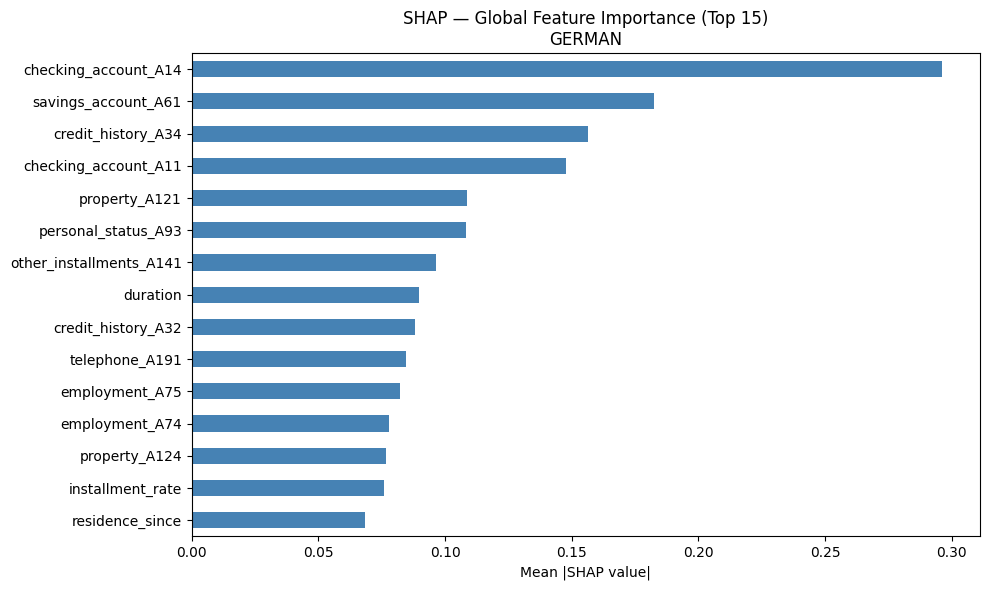


Top 10 features (SHAP):
checking_account_A14       0.296383
savings_account_A61        0.182497
credit_history_A34         0.156488
checking_account_A11       0.147614
property_A121              0.108744
personal_status_A93        0.108387
other_installments_A141    0.096336
duration                   0.089718
credit_history_A32         0.088075
telephone_A191             0.084691
dtype: float64


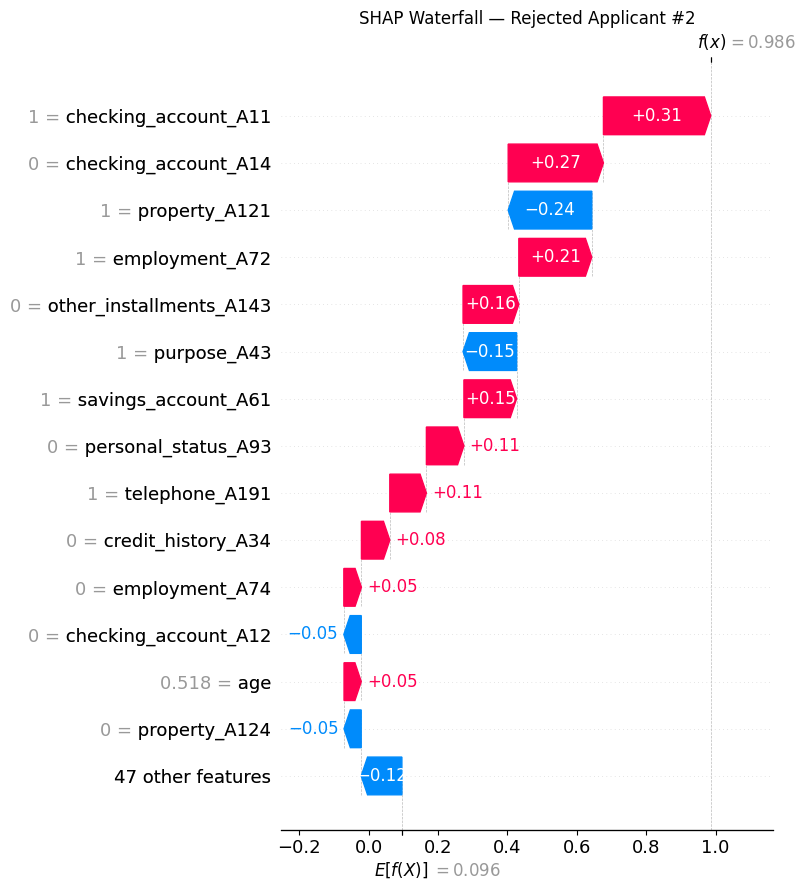

SHAP values saved.


In [ ]:
print("\n" + "="*55)
print("  SHAP — GradientExplainer")
print("="*55)

# Background: train setinden 100 örnek (SHAP için referans dağılımı)
torch.manual_seed(SEED)
bg_idx  = torch.randperm(len(X_train_t))[:100]
bg_data = X_train_t[bg_idx]

# GradientExplainer: FNN gibi gradient-based modeller için uygundur
explainer_shap = shap.GradientExplainer(model, bg_data)

# Test setinin ilk 200 örneği üzerinde SHAP değerleri hesapla
# (tüm test seti pahalı olabilir; 200 iyi bir temsil)
N_SHAP      = min(200, len(X_test_t))
shap_values = explainer_shap.shap_values(X_test_t[:N_SHAP])
# shap_values shape: (N_SHAP, input_dim, 1) → squeeze
shap_values = np.array(shap_values).squeeze()   # (N_SHAP, input_dim)

print(f"SHAP values computed | shape: {shap_values.shape}")

# ── Global Feature Importance (Bar Plot) ────────────────────
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=feature_names)\
                    .sort_values(ascending=False)

plt.figure(figsize=(10, 6))
shap_importance.head(15).plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'SHAP — Global Feature Importance (Top 15)\n{DATASET.upper()}')
plt.xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'outputs',
            f'shap_global_{DATASET}.png'), dpi=150)
plt.show()
print(f"\nTop 10 features (SHAP):\n{shap_importance.head(10)}")

# ── Local Explanation — tek bir reddedilen başvurucu ─────────
# İlk default örneğini bul
default_indices = np.where(y_test.values[:N_SHAP] == 1)[0]
sample_idx      = int(default_indices[0])

shap.waterfall_plot(
    shap.Explanation(
        values       = shap_values[sample_idx],
        base_values  = shap_values.mean(axis=0).sum(),
        data         = X_test.iloc[sample_idx].values,
        feature_names= feature_names
    ),
    max_display=15,
    show=False
)
plt.title(f'SHAP Waterfall — Rejected Applicant #{sample_idx}')
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'outputs',
            f'shap_waterfall_{DATASET}_sample{sample_idx}.png'), dpi=150)
plt.show()

# SHAP değerlerini kaydet (Cell 5'te Consistency için kullanılacak)
np.save(os.path.join(base_path, 'outputs',
        f'shap_values_{DATASET}.npy'), shap_values)
print("SHAP values saved.")



  Integrated Gradients (Captum)
IG attributions computed | shape: (200, 61)


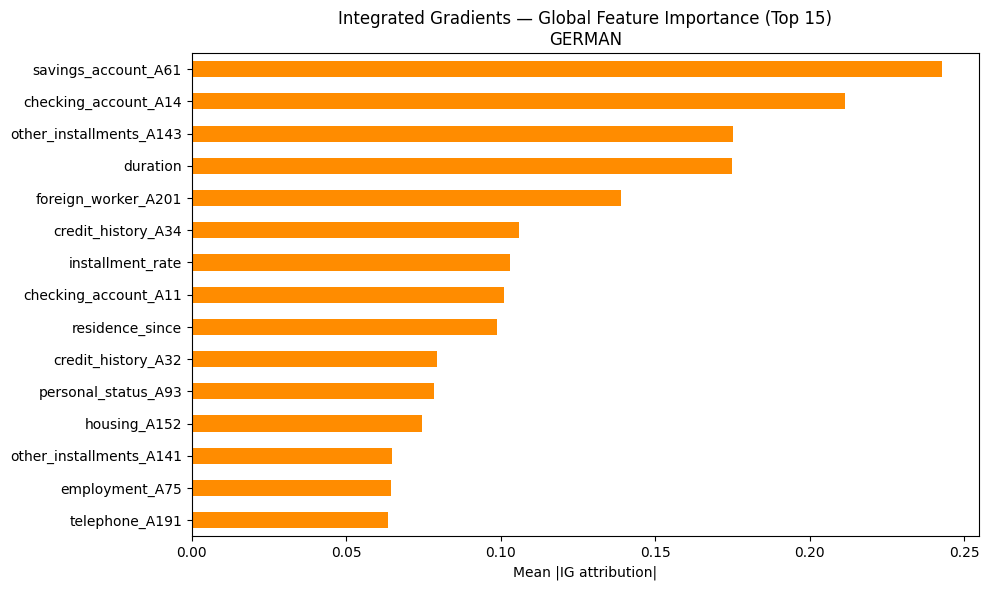


Top 10 features (IG):
savings_account_A61        0.242594
checking_account_A14       0.211233
other_installments_A143    0.175151
duration                   0.174925
foreign_worker_A201        0.138830
credit_history_A34         0.106015
installment_rate           0.103011
checking_account_A11       0.101083
residence_since            0.098900
credit_history_A32         0.079408
dtype: float32


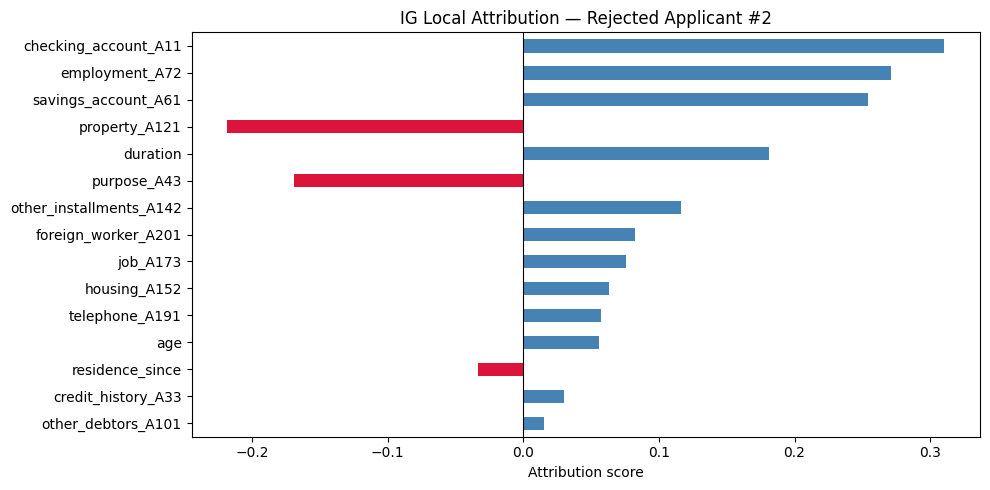

IG values saved.


In [ ]:
print("\n" + "="*55)
print("  Integrated Gradients (Captum)")
print("="*55)

# IG için model'i eval modda, dropout kapat
model.eval()

ig = IntegratedGradients(model)

# Baseline: sıfır vektörü (proposal'da belirtildiği gibi)
baseline = torch.zeros(1, input_dim).to(device)

# Test setinin ilk N_IG örneği
N_IG     = min(200, len(X_test_t))
X_ig     = X_test_t[:N_IG]       # (N_IG, input_dim)

# Captum toplu hesaplama — batch_size=50 ile bellek dostu
batch_size_ig = 50
ig_attrs_list = []

for i in range(0, N_IG, batch_size_ig):
    batch    = X_ig[i:i+batch_size_ig]
    baseline_batch = baseline.expand(len(batch), -1)
    attrs, _ = ig.attribute(
        batch,
        baselines   = baseline_batch,
        return_convergence_delta=True,
        n_steps     = 50      # integral adım sayısı; 50 hız/kalite dengesi
    )
    ig_attrs_list.append(attrs.detach().cpu().numpy())

ig_attrs = np.vstack(ig_attrs_list)   # (N_IG, input_dim)
print(f"IG attributions computed | shape: {ig_attrs.shape}")

# ── Global IG Feature Importance ────────────────────────────
mean_abs_ig = np.abs(ig_attrs).mean(axis=0)
ig_importance = pd.Series(mean_abs_ig, index=feature_names)\
                  .sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ig_importance.head(15).plot(kind='barh', color='darkorange')
plt.gca().invert_yaxis()
plt.title(f'Integrated Gradients — Global Feature Importance (Top 15)\n{DATASET.upper()}')
plt.xlabel('Mean |IG attribution|')
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'outputs',
            f'ig_global_{DATASET}.png'), dpi=150)
plt.show()
print(f"\nTop 10 features (IG):\n{ig_importance.head(10)}")

# ── Local IG — aynı reddedilen başvurucu ────────────────────
ig_sample = ig_attrs[sample_idx]
ig_df = pd.Series(ig_sample, index=feature_names).sort_values(key=abs,
                                                                ascending=False)
plt.figure(figsize=(10, 5))
colors = ['crimson' if v < 0 else 'steelblue' for v in ig_df.head(15)]
ig_df.head(15).plot(kind='barh', color=colors)
plt.gca().invert_yaxis()
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'IG Local Attribution — Rejected Applicant #{sample_idx}')
plt.xlabel('Attribution score')
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'outputs',
            f'ig_local_{DATASET}_sample{sample_idx}.png'), dpi=150)
plt.show()

# IG değerlerini kaydet
np.save(os.path.join(base_path, 'outputs',
        f'ig_values_{DATASET}.npy'), ig_attrs)
print("IG values saved.")



  SHAP vs IG — Consistency Analysis

  K=5
    Feature Agreement      : 0.589 ± 0.180
    Signed Rank Agreement  : 0.589 ± 0.180

  K=10
    Feature Agreement      : 0.547 ± 0.114
    Signed Rank Agreement  : 0.536 ± 0.122

  K=15
    Feature Agreement      : 0.557 ± 0.092
    Signed Rank Agreement  : 0.507 ± 0.097


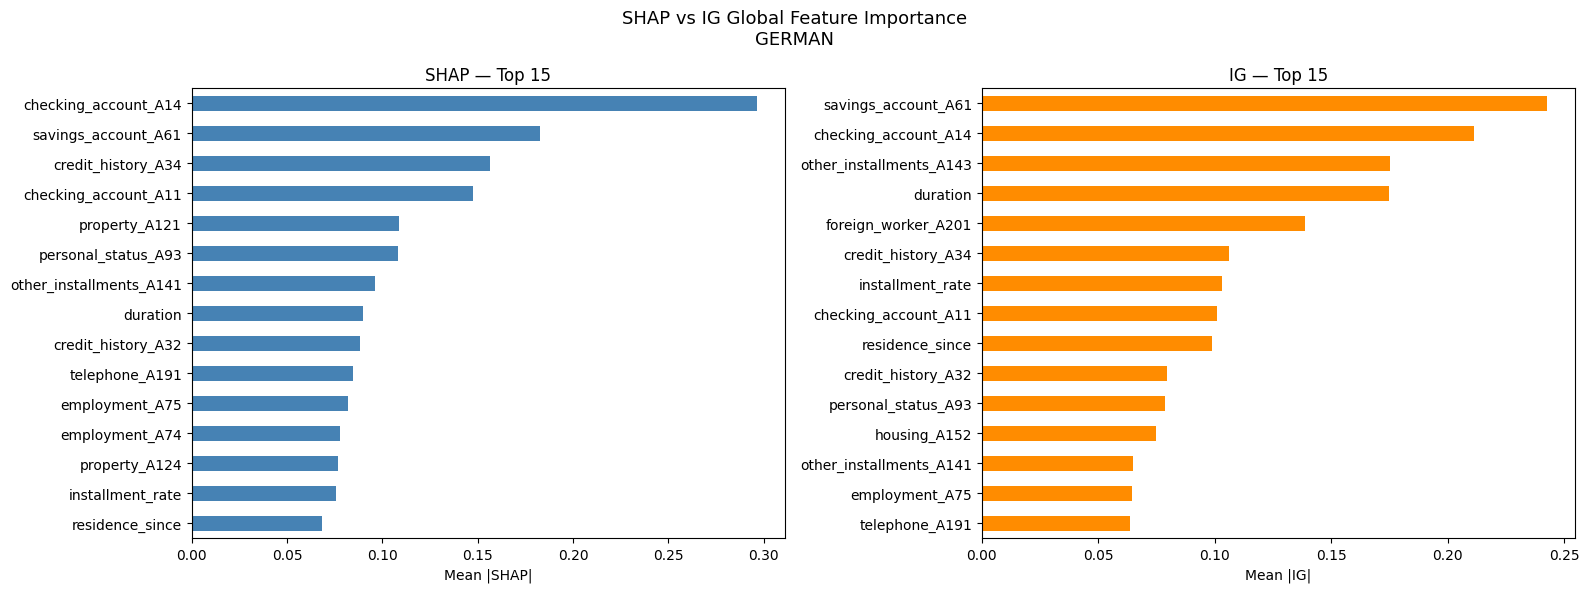


  Top-10 feature overlap (SHAP ∩ IG): 6/10
Consistency results saved.


In [ ]:
print("\n" + "="*55)
print("  SHAP vs IG — Consistency Analysis")
print("="*55)

def topk_agreement(attrs_a, attrs_b, k=10):
    """
    Her örnek için iki metodun top-K feature setinin
    kesişim oranını hesaplar.
    Döndürür: mean overlap score ∈ [0,1]
    """
    scores = []
    for a, b in zip(attrs_a, attrs_b):
        top_a = set(np.argsort(np.abs(a))[-k:])
        top_b = set(np.argsort(np.abs(b))[-k:])
        scores.append(len(top_a & top_b) / k)
    return np.mean(scores), np.std(scores)

def signed_rank_agreement(attrs_a, attrs_b, k=10):
    """
    Top-K feature'ların hem sıralamasını hem işaretini karşılaştırır.
    İki özellik aynı sırada ve aynı işarette ise 1 puan alır.
    """
    scores = []
    for a, b in zip(attrs_a, attrs_b):
        rank_a = np.argsort(np.abs(a))[-k:][::-1]
        rank_b = np.argsort(np.abs(b))[-k:][::-1]
        sign_a = np.sign(a[rank_a])
        sign_b = np.sign(b[rank_b])
        # Sıra ve işaret eşleşmesi
        match = sum(
            1 for i, feat in enumerate(rank_a)
            if feat in rank_b and
               sign_a[i] == sign_b[list(rank_b).index(feat)]
        )
        scores.append(match / k)
    return np.mean(scores), np.std(scores)

# Hesapla
N_common = min(len(shap_values), len(ig_attrs))
sv = shap_values[:N_common]
ig = ig_attrs[:N_common]

for K in [5, 10, 15]:
    fa_mean, fa_std   = topk_agreement(sv, ig, k=K)
    sra_mean, sra_std = signed_rank_agreement(sv, ig, k=K)
    print(f"\n  K={K}")
    print(f"    Feature Agreement      : {fa_mean:.3f} ± {fa_std:.3f}")
    print(f"    Signed Rank Agreement  : {sra_mean:.3f} ± {sra_std:.3f}")

# ── Görsel karşılaştırma: top-15 global ranking ─────────────
K_VIZ = 15
top_shap_feats = shap_importance.head(K_VIZ).index.tolist()
top_ig_feats   = ig_importance.head(K_VIZ).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
shap_importance.head(K_VIZ).plot(kind='barh', ax=axes[0],
                                  color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('SHAP — Top 15')
axes[0].set_xlabel('Mean |SHAP|')

ig_importance.head(K_VIZ).plot(kind='barh', ax=axes[1],
                                color='darkorange')
axes[1].invert_yaxis()
axes[1].set_title('IG — Top 15')
axes[1].set_xlabel('Mean |IG|')

plt.suptitle(f'SHAP vs IG Global Feature Importance\n{DATASET.upper()}',
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'outputs',
            f'shap_vs_ig_{DATASET}.png'), dpi=150)
plt.show()

overlap_top10 = len(set(top_shap_feats[:10]) & set(top_ig_feats[:10]))
print(f"\n  Top-10 feature overlap (SHAP ∩ IG): {overlap_top10}/10")

# Sonuçları kaydet
consistency_results = {
    'dataset': DATASET,
    'top10_overlap': overlap_top10,
}
for K in [5, 10, 15]:
    fa, _  = topk_agreement(sv, ig, k=K)
    sra, _ = signed_rank_agreement(sv, ig, k=K)
    consistency_results[f'FA_K{K}']  = round(fa, 4)
    consistency_results[f'SRA_K{K}'] = round(sra, 4)

pd.DataFrame([consistency_results]).to_csv(
    os.path.join(base_path, 'outputs',
                 f'consistency_{DATASET}.csv'), index=False)
print("Consistency results saved.")

In [ ]:
print("\n" + "="*55)
print("  DiCE — Counterfactual Explanations")
print("="*55)

from sklearn.base import BaseEstimator, ClassifierMixin

class FNNWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model, device):
        self.model  = model
        self.device = device
    def fit(self, X, y):
        return self
    def predict_proba(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        t = torch.tensor(X, dtype=torch.float32).to(self.device)
        self.model.eval()
        with torch.no_grad():
            logits = self.model(t).cpu().numpy().flatten()
        prob_pos = 1 / (1 + np.exp(-logits))
        return np.column_stack([1 - prob_pos, prob_pos])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)
    def score(self, X, y):
        from sklearn.metrics import accuracy_score
        return accuracy_score(y, self.predict(X))

wrapped_model = FNNWrapper(model, device)

# Gerçekten reddedilen: model prob >= 0.5 VE gercek etiket = 1
model_probs_test    = predict_proba(X_test_t)
truly_rejected_mask = (y_test.values == 1) & (model_probs_test >= 0.5)
X_rej = X_test[truly_rejected_mask].reset_index(drop=True)
y_rej = y_test[truly_rejected_mask].reset_index(drop=True)
print(f"Gercekten reddedilen: {len(X_rej)}")

# Immutable feature'lari disla (age de dahil)
IMMUTABLE_KW = [
    "checking_account", "personal_status", "foreign_worker",
    "property", "housing", "job", "telephone", "age"
]
features_to_vary = [f for f in feature_names
                    if not any(kw in f for kw in IMMUTABLE_KW)]
print(f"Vary edilecek feature: {len(features_to_vary)}/{len(feature_names)}")

# DiCE nesneleri
train_df = X_train.copy()
train_df["target"] = y_train.values

dice_data  = dice_ml.Data(
    dataframe           = train_df,
    continuous_features = feature_names,
    outcome_name        = "target"
)
dice_model = dice_ml.Model(model=wrapped_model, backend="sklearn")
exp = dice_ml.Dice(dice_data, dice_model, method="genetic")

N_CF   = min(50, len(X_rej))
NUM_CF = 3
print(f"\n{N_CF} basvurucu icin {NUM_CF} CF uretiliyor...")

validity_scores  = []
proximity_scores = []
cf_records       = []

for i in range(N_CF):
    query = X_rej.iloc[[i]]
    try:
        cf_result = exp.generate_counterfactuals(
            query,
            total_CFs        = NUM_CF,
            desired_class    = 0,
            features_to_vary = features_to_vary,
        )
        cfs_df = cf_result.cf_examples_list[0].final_cfs_df
        if cfs_df is None or len(cfs_df) == 0:
            validity_scores.append(0)
            continue

        cf_feats = cfs_df[feature_names].values
        cf_preds = wrapped_model.predict(cf_feats)
        valid    = int(cf_preds.mean() < 0.5)
        validity_scores.append(valid)

        orig  = query[feature_names].values
        dists = np.abs(cf_feats - orig).mean(axis=1)
        proximity_scores.append(dists.mean())

        cf_records.append({
            "i"          : i,
            "orig_prob"  : wrapped_model.predict_proba(query.values)[:, 1][0],
            "orig_series": query[feature_names].iloc[0],
            "cf_series"  : pd.Series(cfs_df[feature_names].iloc[0]),
            "valid"      : valid,
            "proximity"  : dists.mean()
        })
    except Exception as e:
        print(f"  CF failed #{i}: {e}")
        validity_scores.append(0)

val_rate  = np.mean(validity_scores)
prox_mean = np.mean(proximity_scores) if proximity_scores else float("nan")
print(f"\n  Validity  : {val_rate:.2%}")
print(f"  Proximity : {prox_mean:.4f}")

pd.DataFrame([{
    "dataset": DATASET, "n": N_CF, "num_cfs": NUM_CF,
    "validity": round(val_rate, 4),
    "proximity": round(prox_mean, 4)
}]).to_csv(os.path.join(base_path, "outputs",
           f"dice_summary_{DATASET}.csv"), index=False)

# Kategori kodu -> insan okunabilir aciklama
CATEGORY_LABELS = {
    # Checking account
    "checking_account_A11": "Checking account: negatif bakiye (< 0 DM)",
    "checking_account_A12": "Checking account: 0-200 DM arasi bakiye",
    "checking_account_A13": "Checking account: 200+ DM bakiye",
    "checking_account_A14": "Checking account yok",
    # Savings account
    "savings_account_A61": "Tasarruf: < 100 DM",
    "savings_account_A62": "Tasarruf: 100-500 DM arasi",
    "savings_account_A63": "Tasarruf: 500-1000 DM arasi",
    "savings_account_A64": "Tasarruf: 1000+ DM",
    "savings_account_A65": "Tasarruf hesabi yok / bilgi yok",
    # Employment
    "employment_A71": "Issiz",
    "employment_A72": "1 yildan az suredir calisiyorsunuz",
    "employment_A73": "1-4 yil arasi calisiyorsunuz",
    "employment_A74": "4-7 yil arasi calisiyorsunuz",
    "employment_A75": "7+ yildir calisiyorsunuz",
    # Credit history
    "credit_history_A30": "Kredi gecmisi: hic kredi alinmamis",
    "credit_history_A31": "Kredi gecmisi: bu bankada odenmis",
    "credit_history_A32": "Kredi gecmisi: mevcut krediler duzenli odeniyor",
    "credit_history_A33": "Kredi gecmisi: gecmiste gecikme var",
    "credit_history_A34": "Kredi gecmisi: kritik hesap / baska bankada borc",
    # Purpose
    "purpose_A40": "Amac: yeni araba",
    "purpose_A41": "Amac: ikinci el araba",
    "purpose_A42": "Amac: mobilya / ev esyasi",
    "purpose_A43": "Amac: elektronik / radyo / televizyon",
    "purpose_A44": "Amac: beyaz esya",
    "purpose_A45": "Amac: tamirat",
    "purpose_A46": "Amac: egitim",
    "purpose_A47": "Amac: tatil",
    "purpose_A48": "Amac: yeniden egitim",
    "purpose_A49": "Amac: is kurma",
    "purpose_A410": "Amac: diger",
    # Other installments
    "other_installments_A141": "Diger taksit: baska bankada",
    "other_installments_A142": "Diger taksit: magazalarda",
    "other_installments_A143": "Diger taksit yok",
    # Other debtors
    "other_debtors_A101": "Kefil / ortak borc yoktur",
    "other_debtors_A102": "Ortak borclu var",
    "other_debtors_A103": "Kefil var",
    # Numerical
    "duration"        : "Kredi suresi (ay)",
    "credit_amount"   : "Kredi miktari (DM)",
    "installment_rate": "Taksit orani (gelirin yuzdesi)",
    "residence_since" : "Mevcut adreste ikamet suresi (yil)",
    "existing_credits": "Mevcut kredi sayisi",
    "dependents"      : "Bakmakla yukumlu olunan kisi sayisi",
}

def is_onehot_feature(feat):
    parts = feat.split("_A")
    if len(parts) < 2:
        return False
    return parts[-1].isdigit()

def action_plan(orig_s, cf_s, threshold=0.05, max_actions=5):
    actions = []
    for feat in features_to_vary:
        orig_val = float(orig_s[feat])
        cf_val   = float(cf_s[feat])
        delta    = cf_val - orig_val
        if abs(delta) < threshold:
            continue
        pct       = abs(delta) * 100
        label     = CATEGORY_LABELS.get(feat, feat)   # kod yoksa ham isim
        direction = "artirmaniz" if delta > 0 else "azaltmaniz"

        if is_onehot_feature(feat):
            if delta > 0:
                msg = f"  [+] {label} onaylanma ihtimalinizi arttirir."
            else:
                msg = f"  [-] {label} durumundan cikmak onaylanma ihtimalinizi arttirir."
        else:
            msg = (f"  [>] {label} degerini yaklasik %{pct:.0f} {direction} "
                   f"onaylanma ihtimalinizi arttirir. "
                   f"(mevcut: {orig_val:.2f} -> onerilen: {cf_val:.2f})")
        actions.append((abs(delta), msg))
    actions.sort(key=lambda x: x[0], reverse=True)
    return [a[1] for a in actions[:max_actions]]

print("\n" + "="*60)
print("  ACTION PLANS - Ilk 5 Basvurucu")
print("="*60)

ap_records = []
for rec in cf_records[:5]:
    i         = rec["i"]
    orig_prob = rec["orig_prob"]
    orig_s    = rec["orig_series"]
    cf_s      = rec["cf_series"].reindex(feature_names).fillna(orig_s)

    print(f"\n  Basvurucu #{i}  (Default olasiligi: %{orig_prob*100:.1f})")
    print(f"  {'-'*50}")
    steps = action_plan(orig_s, cf_s)
    if steps:
        for s in steps:
            print(s)
    else:
        print("  Minimal degisiklik yeterli.")

    ap_records.append({
        "applicant"   : i,
        "default_prob": round(orig_prob, 4),
        "plan"        : " | ".join(steps)
    })

pd.DataFrame(ap_records).to_csv(
    os.path.join(base_path, "outputs",
                 f"dice_action_plans_{DATASET}.csv"), index=False)
print("\n  Action plans saved.")
print("\nDiCE done.")


  DiCE — Counterfactual Explanations
Gercekten reddedilen: 42
Vary edilecek feature: 37/61

42 basvurucu icin 3 CF uretiliyor...


100%|██████████| 1/1 [00:04<00:00,  4.48s/it]


  CF failed #9: No counterfactuals found for any of the query points! Kindly check your configuration.


100%|██████████| 1/1 [00:00<00:00,  4.06it/s]



  Validity  : 97.62%
  Proximity : 0.0784

  ACTION PLANS - Ilk 5 Basvurucu

  Basvurucu #0  (Default olasiligi: %66.0)
  --------------------------------------------------
  [-] Kredi gecmisi: gecmiste gecikme var durumundan cikmak onaylanma ihtimalinizi arttirir.
  [-] 1 yildan az suredir calisiyorsunuz durumundan cikmak onaylanma ihtimalinizi arttirir.
  [+] 7+ yildir calisiyorsunuz onaylanma ihtimalinizi arttirir.
  [-] Diger taksit: magazalarda durumundan cikmak onaylanma ihtimalinizi arttirir.
  [+] Diger taksit yok onaylanma ihtimalinizi arttirir.

  Basvurucu #1  (Default olasiligi: %60.5)
  --------------------------------------------------
  [+] Amac: ikinci el araba onaylanma ihtimalinizi arttirir.
  [-] Amac: mobilya / ev esyasi durumundan cikmak onaylanma ihtimalinizi arttirir.
  [+] 7+ yildir calisiyorsunuz onaylanma ihtimalinizi arttirir.
  [>] Mevcut kredi sayisi degerini yaklasik %33 azaltmaniz onaylanma ihtimalinizi arttirir. (mevcut: 0.33 -> onerilen: 0.00)
  [>] Me

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# ── Rebuild CreditFNN ─────────────────────────────────────────
class CreditFNN(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1)
        )
    def forward(self, x):
        return self.net(x)

SEED      = 42
base_path = '/content/drive/MyDrive/capstone'
DATASET   = "german"   # change to match the dataset you ran earlier

# ── Reload splits from Drive ──────────────────────────────────
d       = os.path.join(base_path, 'data', DATASET)
X_train = pd.read_csv(os.path.join(d, 'X_train_fnn.csv'))
X_test  = pd.read_csv(os.path.join(d, 'X_test_fnn.csv'))
y_train = pd.read_csv(os.path.join(d, 'y_train.csv')).squeeze()
y_test  = pd.read_csv(os.path.join(d, 'y_test.csv')).squeeze()

feature_names = X_train.columns.tolist()
input_dim     = len(feature_names)

# ── Reload model from Drive ───────────────────────────────────
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = CreditFNN(input_dim).to(device)
ckpt_path = os.path.join(base_path, 'models', f'fnn_best_{DATASET}.pt')
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()
print(f"Model loaded | input_dim={input_dim} | device={device}")

# ── Reload SHAP and IG arrays saved from earlier cells ───────
shap_values = np.load(os.path.join(base_path, 'outputs',
                      f'shap_values_{DATASET}.npy'))
ig_attrs    = np.load(os.path.join(base_path, 'outputs',
                      f'ig_values_{DATASET}.npy'))
print(f"SHAP values loaded : {shap_values.shape}")
print(f"IG   values loaded : {ig_attrs.shape}")

print("\n" + "="*55)
print("  OpenXAI -- Faithfulness & Stability")
print("="*55)


# ── Shared gradient helper ────────────────────────────────────
def get_input_gradient(model, x_np, device):
    """
    Input gradient of model output w.r.t. a single sample.
    Uses torch.autograd.grad — works correctly through BatchNorm1d.
    x_np : 1-D numpy array (input_dim,)
    Returns: 1-D numpy array (input_dim,)
    """
    x_t = torch.tensor(x_np, dtype=torch.float32).unsqueeze(0).to(device)
    x_t.requires_grad_(True)
    out = model(x_t).squeeze()
    grads = torch.autograd.grad(out, x_t)[0]
    return grads.detach().cpu().numpy().flatten()


# ── Faithfulness ─────────────────────────────────────────────
def faithfulness(model, device, X_np, attrs, k=10):
    """
    Zero out the top-K features by attribution magnitude,
    measure the resulting drop in predicted probability.
    Higher drop = attribution correctly identifies what the model uses.
    Returns (mean_drop, std_drop).
    """
    model.eval()
    orig_t = torch.tensor(X_np, dtype=torch.float32).to(device)
    with torch.no_grad():
        orig_probs = torch.sigmoid(model(orig_t)).cpu().numpy().flatten()

    drops = []
    for i in range(len(X_np)):
        top_k_idx = np.argsort(np.abs(attrs[i]))[-k:]
        perturbed = X_np[i].copy()
        perturbed[top_k_idx] = 0.0
        p_t = torch.tensor(perturbed, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            pert_prob = torch.sigmoid(model(p_t)).item()
        drops.append(abs(orig_probs[i] - pert_prob))
    return np.mean(drops), np.std(drops)


# ── Stability ────────────────────────────────────────────────
def stability(model, device, X_np, n_neighbors=5, noise_std=0.01):
    """
    Relative Input Stability (RIS) — apples-to-apples version.

    Compares input gradients of the ORIGINAL sample against input
    gradients of NOISY NEIGHBOURS. Both sides use the same attribution
    method (input gradients), so the comparison is fair.

    This matches the OpenXAI paper's RIS definition:
        RIS = 1 - mean( ||grad(x) - grad(x')|| / ||grad(x)|| )

    RIS close to 1 = stable (small input change -> small attribution change)
    RIS close to 0 = unstable

    Returns (ris_score, std_of_per_sample_diffs).
    """
    model.eval()
    diffs = []
    for i in range(len(X_np)):
        orig_attr      = get_input_gradient(model, X_np[i], device)
        neighbor_diffs = []
        for _ in range(n_neighbors):
            noisy = X_np[i] + np.random.normal(0, noise_std, X_np[i].shape)
            noisy = np.clip(noisy, 0, 1)
            neigh_attr = get_input_gradient(model, noisy, device)

            denom = np.linalg.norm(orig_attr) + 1e-8
            neighbor_diffs.append(
                np.linalg.norm(orig_attr - neigh_attr) / denom
            )
        diffs.append(np.mean(neighbor_diffs))

    mean_diff = np.mean(diffs)
    ris_score = max(0.0, 1.0 - mean_diff)
    return ris_score, np.std(diffs)


# ── Evaluation subset ────────────────────────────────────────
X_test_t = torch.tensor(X_test.values, dtype=torch.float32).to(device)
N_EVAL   = min(100, len(X_test_t))
X_eval   = X_test.values[:N_EVAL]
sv_eval  = shap_values[:N_EVAL]
ig_eval  = ig_attrs[:N_EVAL]

# ── Run Faithfulness ─────────────────────────────────────────
print("\n  --- Faithfulness (top-K zeroing) ---")
print("  [Uses stored SHAP/IG attributions to select which features to zero]")
faith_results = {}
for K in [5, 10]:
    f_shap, f_shap_std = faithfulness(model, device, X_eval, sv_eval, k=K)
    f_ig,   f_ig_std   = faithfulness(model, device, X_eval, ig_eval, k=K)
    print(f"  K={K} | SHAP: {f_shap:.4f} +/- {f_shap_std:.4f} | "
          f"IG: {f_ig:.4f} +/- {f_ig_std:.4f}")
    faith_results[K] = (f_shap, f_ig)

# ── Run Stability ────────────────────────────────────────────
print("\n  --- Stability (Relative Input Stability) ---")
print("  [Compares input gradients of original vs noisy neighbours]")
ris_score, ris_std = stability(model, device, X_eval,
                                n_neighbors=5, noise_std=0.01)
print(f"  RIS : {ris_score:.4f} +/- {ris_std:.4f}  (target > 0.80)")

# ── Save results to CSV ───────────────────────────────────────
openxai_results = pd.DataFrame([{
    'dataset'        : DATASET,
    'faith_shap_k5'  : round(faith_results[5][0],  4),
    'faith_ig_k5'    : round(faith_results[5][1],  4),
    'faith_shap_k10' : round(faith_results[10][0], 4),
    'faith_ig_k10'   : round(faith_results[10][1], 4),
    'ris'            : round(ris_score, 4),
    'ris_std'        : round(ris_std,   4),
}])
out_csv = os.path.join(base_path, 'outputs', f'openxai_results_{DATASET}.csv')
openxai_results.to_csv(out_csv, index=False)
print(f"\n  OpenXAI results saved -> {out_csv}")
print("\n" + "="*55)
print("  Stage 2 complete.")
print("="*55)

Model loaded | input_dim=61 | device=cpu
SHAP values loaded : (200, 61)
IG   values loaded : (200, 61)

  OpenXAI -- Faithfulness & Stability

  --- Faithfulness (top-K zeroing) ---
  [Uses stored SHAP/IG attributions to select which features to zero]
  K=5 | SHAP: 0.1466 +/- 0.0977 | IG: 0.1683 +/- 0.1055
  K=10 | SHAP: 0.1639 +/- 0.1158 | IG: 0.1713 +/- 0.1175

  --- Stability (Relative Input Stability) ---
  [Compares input gradients of original vs noisy neighbours]
  RIS : 0.9454 +/- 0.0516  (target > 0.80)

  OpenXAI results saved -> /content/drive/MyDrive/capstone/outputs/openxai_results_german.csv

  Stage 2 complete.
